# RSSD demo (Jupyter)

End-to-end **Response Surface Sampling Design** for a 2-signal EMI transect survey.

This notebook follows the ESAP-RSSD workflow:

1. Load survey data from a local file path
2. Natural-log transform, standardize, and PCA on ECa
3. ESAP sigma validation (mask > 3.5 sigma, delete outliers > 4.5 sigma)
4. Match design levels in PC space and swap for spatial uniformity (AD)
5. Export selected calibration sites and review map + PC diagnostics

Edit the config cell below, then run cells top to bottom.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from rssdpy.features import ECaPCA, iterative_esap_validation
from rssdpy.io import selected_sites_table
from rssdpy.io.loaders import validate_canonical_survey
from rssdpy.sampling import esap_sample_plan, esap_sampling_design, run_rssd
from rssdpy.viz import plot_pc_scatter

In [11]:
# Config (edit as needed)
survey_path_default = Path("../examples/data/101710A_for_esap.txt")
survey_path = survey_path_default  # edit this path for your survey file

crs = "EPSG:6339"
eca_columns = ["EMv", "EMh"]
headerless_columns = ["x", "y", "EMv", "EMh", "row"]

target_size = 12
design_factor = 1.0
n_components = 2

output_dir = Path("artifacts")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Survey path: {survey_path}")
print(f"CRS: {crs}")
print(f"target_size={target_size}, design_factor={design_factor:.2f}")

Survey path: ../examples/data/101710A_for_esap.txt
CRS: EPSG:6339
target_size=12, design_factor=1.00


In [12]:
if not survey_path.exists():
    raise FileNotFoundError(f"Survey file not found: {survey_path}")

suffix = survey_path.suffix.lower().lstrip(".")
if suffix not in {"csv", "txt"}:
    raise ValueError(f"Unsupported file extension: .{suffix}. Use .csv or .txt")

required = {"x", "y", *eca_columns}

if suffix == "txt":
    raw = pd.read_csv(survey_path, header=None, names=headerless_columns)
    if raw[eca_columns].isna().all().all():
        raw = pd.read_csv(
            survey_path,
            sep=r"\s+",
            header=None,
            names=headerless_columns,
            engine="python",
        )
else:
    raw = pd.read_csv(survey_path)
    if not required.issubset(raw.columns):
        raw = pd.read_csv(survey_path, header=None, names=headerless_columns)

if "site_id" not in raw.columns:
    raw.insert(0, "site_id", np.arange(1, len(raw) + 1))

canonical = validate_canonical_survey(
    raw,
    eca_columns=eca_columns,
    crs=crs,
    require_projected_crs=True,
)
eca = canonical[eca_columns].copy()
coords = canonical[["x", "y"]].to_numpy(dtype=float)
source_name = survey_path.name

In [14]:
n_sites = len(eca)
log_emv_mean = float(np.log(eca["EMv"]).mean())
log_emh_mean = float(np.log(eca["EMh"]).mean())
x_min, x_max = float(coords[:, 0].min()), float(coords[:, 0].max())
y_min, y_max = float(coords[:, 1].min()), float(coords[:, 1].max())

summary = pd.DataFrame(
    {
        "Metric": [
            "Survey file",
            "CRS",
            "Sites loaded",
            "X range",
            "Y range",
            "mean(ln EMv)",
            "mean(ln EMh)",
        ],
        "Value": [
            source_name,
            crs,
            n_sites,
            f"{x_min:.1f} - {x_max:.1f}",
            f"{y_min:.1f} - {y_max:.1f}",
            f"{log_emv_mean:.4f}",
            f"{log_emh_mean:.4f}",
        ],
    }
)

display(Markdown("### Load summary"))
display(summary)
display(eca.describe().round(2))

### Load summary

,Metric,Value
0,Survey file,101710A_for_esap.txt
1,CRS,EPSG:6339
2,Sites loaded,5102
3,X range,709107.5 - 709684.4
4,Y range,4085780.4 - 4086357.9
5,mean(ln EMv),5.6932
6,mean(ln EMh),5.5215


,EMv,EMh
count,5102.00,5102.00
mean,315.95,273.94
std,102.65,106.90
min,73.01,54.84
25%,234.63,182.55
50%,318.16,276.21
75%,406.18,364.53
max,528.79,528.36


In [15]:
pca = ECaPCA(n_components=n_components)
eca_clean, scores, qc, original_idx = iterative_esap_validation(eca, pca)

n_masked = int(qc.masking_mask.sum())
n_eligible = int(qc.eligible_mask.sum())
n_removed = len(eca) - len(eca_clean)

qc_summary = pd.DataFrame(
    {
        "Step": [
            "Masked (> 3.5 sigma)",
            "Outliers deleted (> 4.5 sigma)",
            "Eligible for RSSD",
            "Sites after QC",
        ],
        "Count": [n_masked, n_removed, n_eligible, len(eca_clean)],
    }
)

display(Markdown("### ESAP sigma validation"))
display(qc_summary)

### ESAP sigma validation

,Step,Count
0,Masked (> 3.5 sigma),72
1,Outliers deleted (> 4.5 sigma),1
2,Eligible for RSSD,5029
3,Sites after QC,5101


In [16]:
coords_clean = coords[original_idx]

plan = esap_sample_plan(
    n_components=n_components,
    target_size=int(target_size),
    design_factor=float(design_factor),
    design_mode="esap_two_signal",
)
design = esap_sampling_design(
    n_components=n_components,
    design_mode="esap_two_signal",
    design_factor=float(design_factor),
)
result = run_rssd(
    scores,
    coords_clean,
    design,
    n_extra=plan.n_extra,
    extra_mode="cube",
    eligible_mask=qc.eligible_mask,
    original_indices=original_idx,
    design_factor=float(design_factor),
    opt_criteria_mode="esap",
)

selected_site_ids = sorted((result.selected_original_indices + 1).tolist())

rssd_summary = pd.DataFrame(
    {
        "Metric": [
            "Target sample size",
            "Core design levels",
            "Support sites",
            "Total selected",
            "D-Factor",
            "AD initial (m)",
            "AD final (m)",
            "Opt-Criteria",
            "Swaps accepted",
        ],
        "Value": [
            int(target_size),
            len(result.design_level_indices),
            len(result.extra_indices),
            len(result.selected_indices),
            f"{result.design_factor:.2f}",
            f"{result.ad_initial:.2f}",
            f"{result.ad_final:.2f}",
            f"{result.opt_criteria:.3f}",
            result.swap_count,
        ],
    }
)

display(Markdown("### RSSD results"))
display(rssd_summary)
print("Selected site IDs:", selected_site_ids)

### RSSD results

,Metric,Value
0,Target sample size,12
1,Core design levels,10
2,Support sites,2
3,Total selected,12
4,D-Factor,1.00
5,AD initial (m),83.84
6,AD final (m),72.00
7,Opt-Criteria,1.296
8,Swaps accepted,7


Selected site IDs: [154, 435, 699, 1650, 2227, 2403, 3090, 3732, 3940, 4276, 4614, 5064]


In [17]:
table_sorted = (
    selected_sites_table(result, coords_clean, design=design)
    .sort_values("selection_order")
    .reset_index(drop=True)
)

selected_csv_path = output_dir / f"{survey_path.stem}_selected_sites.csv"
table_sorted.to_csv(selected_csv_path, index=False)

display(Markdown("### Selected calibration sites"))
display(table_sorted)
print(f"Saved selected sites CSV: {selected_csv_path}")

### Selected calibration sites

,selected_index,site_id,selected_original_index,selection_order,selection_type,ad_final_m,opt_criteria,design_factor,x,y,design_pc1,design_pc2
0,2401,2403,2402,1,core,72.00383,1.296309,1.0,709442.771,4085894.989,0.75,0.00
1,1649,1650,1649,2,core,72.00383,1.296309,1.0,709513.514,4086189.741,1.75,1.75
2,5062,5064,5063,3,core,72.00383,1.296309,1.0,709111.072,4086222.298,-1.75,-1.75
3,434,435,434,4,core,72.00383,1.296309,1.0,709651.059,4085945.103,1.75,-1.75
4,3730,3732,3731,5,core,72.00383,1.296309,1.0,709291.684,4085938.323,-1.75,1.75
5,153,154,153,6,core,72.00383,1.296309,1.0,709671.749,4086107.615,2.50,0.00
6,4612,4614,4613,7,core,72.00383,1.296309,1.0,709167.715,4085997.398,-2.50,0.00
7,2226,2227,2226,8,core,72.00383,1.296309,1.0,709428.655,4086302.310,0.00,2.50
8,3938,3940,3939,9,core,72.00383,1.296309,1.0,709257.926,4086162.687,0.00,-2.50
9,698,699,698,10,core,72.00383,1.296309,1.0,709612.618,4086287.857,-0.75,0.00


Saved selected sites CSV: artifacts/101710A_for_esap_selected_sites.csv


### Map

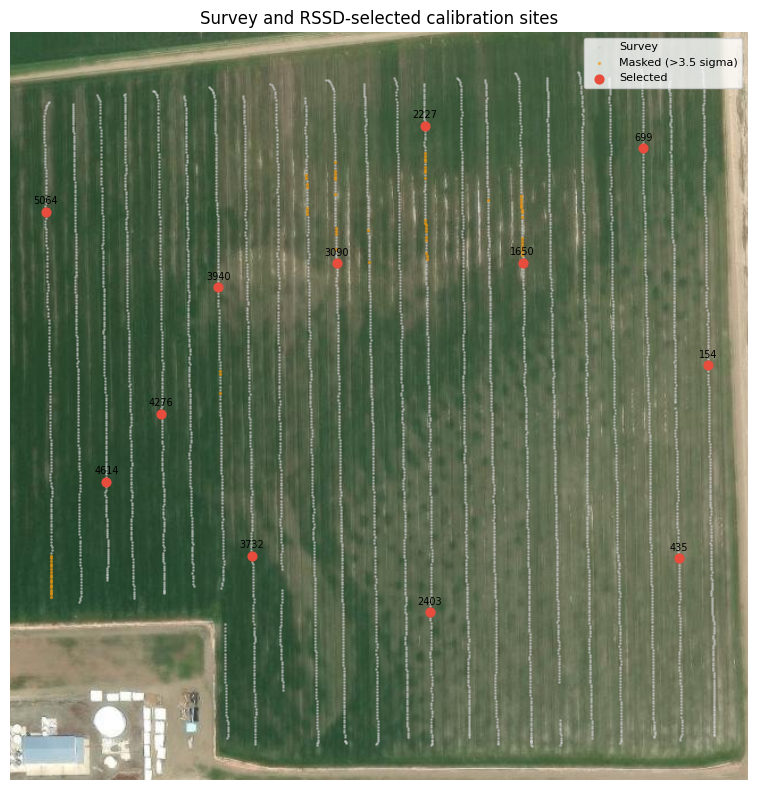

In [18]:
display(Markdown("### Map"))
try:
    import contextily as ctx_basemap
    import geopandas as gpd

    n_total = len(coords)
    site_ids = np.arange(1, n_total + 1)
    selected_original_idx = result.selected_original_indices

    eligible_full = np.zeros(n_total, dtype=bool)
    eligible_full[original_idx] = qc.eligible_mask
    masked_full = ~eligible_full

    gdf = gpd.GeoDataFrame(
        {
            "site_id": site_ids,
            "masked": masked_full,
            "selected": np.isin(np.arange(n_total), selected_original_idx),
        },
        geometry=gpd.points_from_xy(coords[:, 0], coords[:, 1]),
        crs=crs,
    )
    gdf_web = gdf.to_crs(3857)

    fig_full, ax_full = plt.subplots(figsize=(10, 8))
    background = gdf_web[~gdf_web["selected"] & ~gdf_web["masked"]]
    masked_pts = gdf_web[gdf_web["masked"]]
    selected_pts = gdf_web[gdf_web["selected"]]

    if len(background):
        background.plot(ax=ax_full, color="#cccccc", markersize=1, alpha=0.5, label="Survey")
    if len(masked_pts):
        masked_pts.plot(
            ax=ax_full,
            color="#f39c12",
            markersize=2,
            alpha=0.6,
            label="Masked (>3.5 sigma)",
        )
    if len(selected_pts):
        selected_pts.plot(
            ax=ax_full,
            color="#e74c3c",
            markersize=40,
            label="Selected",
            zorder=5,
        )

    for x_full, y_full, sid_full in zip(
        selected_pts.geometry.x,
        selected_pts.geometry.y,
        selected_pts["site_id"],
        strict=True,
    ):
        ax_full.annotate(
            str(int(sid_full)),
            (x_full, y_full),
            fontsize=7,
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
        )

    ctx_basemap.add_basemap(
        ax_full,
        source="Esri.WorldImagery",
        attribution=False,
    )
    ax_full.set_axis_off()
    ax_full.set_title("Survey and RSSD-selected calibration sites")
    ax_full.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()
except ImportError:
    print(
        "Map skipped: install geopandas and contextily to enable basemap plotting in this notebook."
    )

### PC scatter

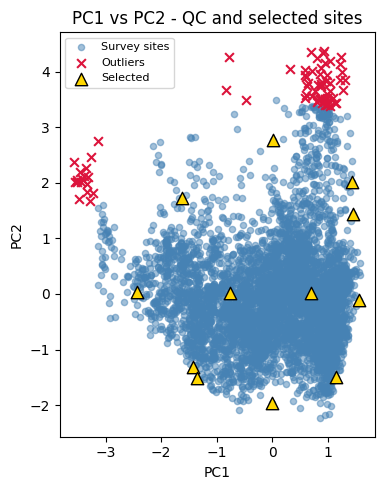

In [19]:
display(Markdown("### PC scatter"))
fig_pc, ax_pc = plt.subplots(figsize=(6, 5))
plot_pc_scatter(
    scores,
    outlier_mask=~qc.eligible_mask,
    selected_indices=result.selected_indices,
    ax=ax_pc,
)
ax_pc.set_title("PC1 vs PC2 - QC and selected sites")
plt.tight_layout()
plt.show()